# Núcleo 4 — Peso de la coparticipación en las cuentas de Córdoba

Este notebook calcula qué porcentaje de los ingresos corrientes totales de la
provincia de Córdoba proviene de la coparticipación federal, y usa el simulador del
Núcleo 3 para traducir un shock de recaudación nacional coparticipable en un impacto
sobre el ingreso provincial total — un indicador simple de vulnerabilidad fiscal.

**Fuentes**: coparticipación nominal de Córdoba (Núcleo 1,
`data/processed/coparticipacion_real.csv`) e ingresos corrientes totales (proxy),
de `data/raw/ingresos_cordoba/serie_recaudacion_provincial.xlsx`.

**Qué es "ingresos corrientes totales" acá (decisión documentada, no la única
posible)**: la fila "Total" del archivo de recaudación provincial — Recursos de Origen
Provincial + Recursos de Origen Nacional administrados por la Dirección General de
Rentas de Córdoba. Esto **excluye** lo recaudado por otros organismos públicos
provinciales (p. ej. EPEC), según la propia nota al pie del archivo fuente. Es la mejor
proxy disponible, confirmada con el usuario antes de integrarla, pero no es el ingreso
corriente total del sector público provincial en sentido estricto de ejecución
presupuestaria. Ver `docs/methodology.md` para el detalle completo, incluida la
verificación de que los valores del archivo están en pesos (no en "millones de pesos"
como dice su propio encabezado).

**Alcance**: 2015-2025 (11 años) — el archivo de ingresos empieza en enero de 2015;
2026 queda afuera por ser un año calendario incompleto en ambas fuentes.

**Fuente de los datos procesados**: `data/processed/dependencia_fiscal_cordoba.csv`,
generado por `scripts/build_dependencia_fiscal.py`.


In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

BASE_DIR = Path("..").resolve() if Path("../data").exists() else Path(".").resolve()
sys.path.insert(0, str(BASE_DIR / "scripts"))

from build_dependencia_fiscal import build_ratio, calcular_sensibilidad

COLOR_RATIO = "#2a78d6"
COLOR_NEGATIVO = "#e34948"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
})

FIGURES_DIR = BASE_DIR / "output" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = build_ratio()
df


AVISO: años con menos de 12 meses de datos (se descartan del ratio anual, no se completan con supuestos): [2026]


,anio,coparticipacion_nominal_pesos,ingresos_totales_pesos,ratio_coparticipacion_ingresos
0,2015,2.367304e+10,6.578461e+10,0.359857
1,2016,3.570138e+10,9.201533e+10,0.387994
2,2017,4.794422e+10,1.221641e+11,0.392458
3,2018,7.878438e+10,1.640963e+11,0.480111
4,2019,1.120619e+11,2.270608e+11,0.493532
5,2020,1.474505e+11,3.062720e+11,0.481436
6,2021,2.423711e+11,5.031439e+11,0.481713
7,2022,4.636073e+11,8.982800e+11,0.516106
8,2023,1.014210e+12,1.965302e+12,0.516058
9,2024,3.069566e+12,5.945371e+12,0.516295


## 1. Evolución del ratio coparticipación / ingresos totales (2015-2025)


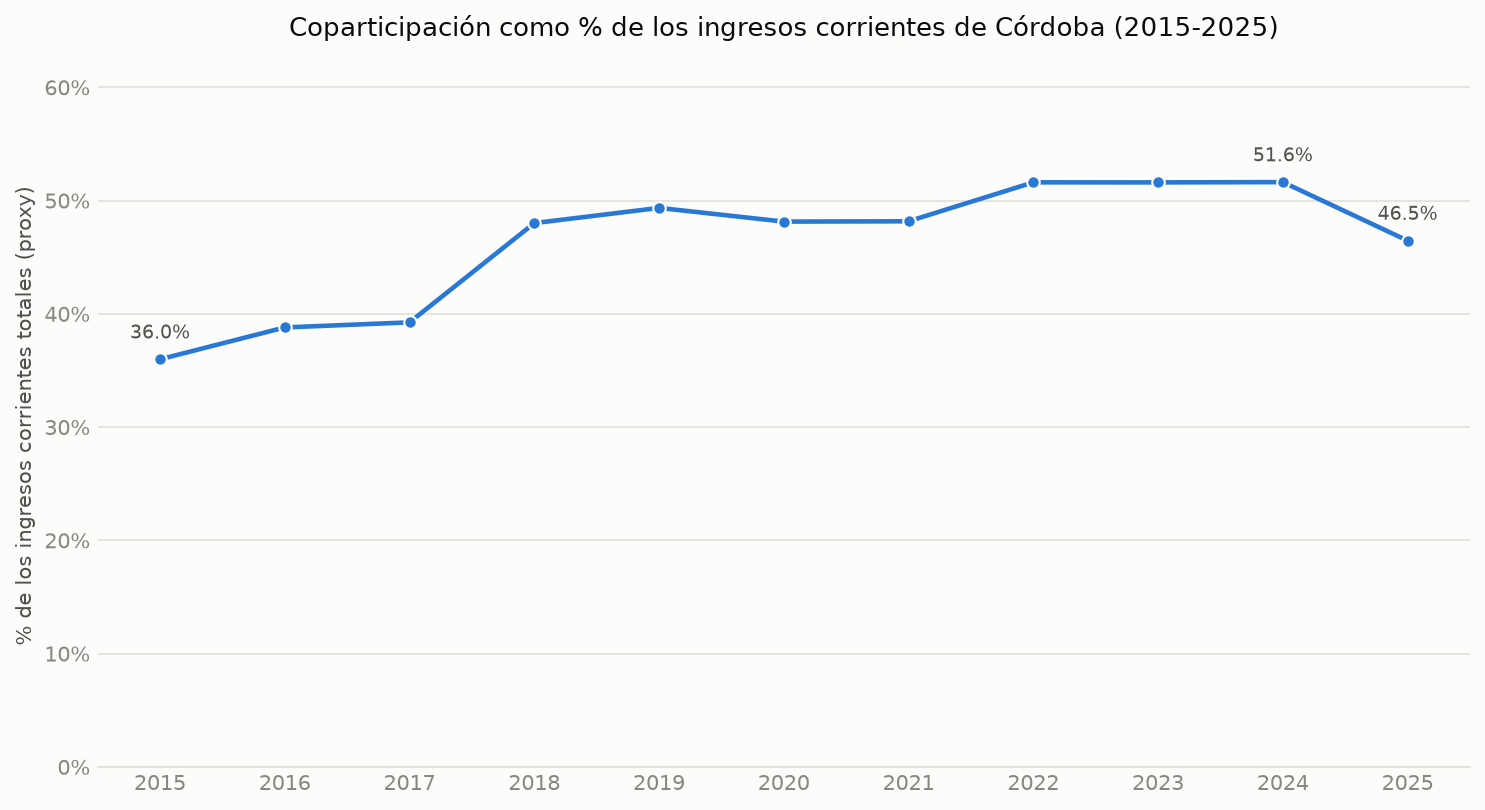

In [2]:
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)
ax.plot(
    df["anio"], df["ratio_coparticipacion_ingresos"] * 100,
    color=COLOR_RATIO, linewidth=2.2, marker="o", markersize=6,
    markerfacecolor=COLOR_RATIO, markeredgecolor=SURFACE, markeredgewidth=1,
)

idx_max = df["ratio_coparticipacion_ingresos"].idxmax()
for idx in sorted(set([df.index[0], idx_max, df.index[-1]])):
    row = df.loc[idx]
    ax.annotate(
        f"{row['ratio_coparticipacion_ingresos']:.1%}",
        (row["anio"], row["ratio_coparticipacion_ingresos"] * 100),
        textcoords="offset points", xytext=(0, 10), ha="center",
        fontsize=9, color=INK_SECONDARY,
    )

ax.set_title("Coparticipación como % de los ingresos corrientes de Córdoba (2015-2025)", fontsize=12.5, color=INK_PRIMARY, pad=14)
ax.set_ylabel("% de los ingresos corrientes totales (proxy)", fontsize=10)
ax.set_xlabel("")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_ylim(0, max(df["ratio_coparticipacion_ingresos"] * 100) * 1.2)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRID_COLOR)
ax.tick_params(axis="both", length=0)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "dependencia_fiscal_cordoba.png", dpi=300, facecolor=SURFACE)
plt.show()


**Lectura**: la coparticipación pasó de representar el 36% de los ingresos corrientes
de Córdoba en 2015 a más del 51% en 2022-2024, y bajó a 46,5% en 2025. La tendencia de
fondo es un aumento sostenido de la dependencia de transferencias nacionales a lo largo
de la década, con una leve reversión en el último año de la serie.


## 2. Indicador de sensibilidad: shock de recaudación nacional → impacto en el ingreso provincial

Usando el simulador del Núcleo 3 (`scripts/simulator.py`), se traduce una caída
porcentual de la recaudación tributaria nacional coparticipable en un impacto en pesos
sobre la coparticipación de Córdoba, y ese impacto se expresa como % de sus ingresos
corrientes totales de 2025 (año de referencia, el más reciente disponible en ambas
fuentes).


In [3]:
sensibilidad = calcular_sensibilidad(anio_referencia=2025, escenarios=[-0.05, -0.10])
tabla = sensibilidad.copy()
tabla["variacion_pct_recaudacion"] = tabla["variacion_pct_recaudacion"].map(lambda x: f"{x:.0%}")
tabla["impacto_copart_cordoba_pesos"] = tabla["impacto_copart_cordoba_pesos"].map(lambda x: f"${x/1e9:,.1f} mil M")
tabla["impacto_pct_ingresos_totales_cordoba"] = tabla["impacto_pct_ingresos_totales_cordoba"].map(lambda x: f"{x:.2%}")
tabla.columns = ["Variación recaudación coparticipable", "Impacto en coparticipación de Córdoba", "Impacto en ingresos totales de Córdoba"]
tabla


AVISO: años con menos de 12 meses de datos (se descartan del ratio anual, no se completan con supuestos): [2026]


,Variación recaudación coparticipable,Impacto en coparticipación de Córdoba,Impacto en ingresos totales de Córdoba
0,-5%,$-209.9 mil M,-2.35%
1,-10%,$-419.8 mil M,-4.70%


**Lectura**: una caída del 5% en la recaudación tributaria nacional coparticipable
reduce el ingreso corriente total de Córdoba en aproximadamente **2,3%**; una caída del
10% lo reduce en aproximadamente **4,7%**. El indicador es prácticamente lineal en la
magnitud del shock (la elasticidad es, por construcción, cercana al ratio
coparticipación/ingresos de 2025: ~46,5%) — es una simplificación deliberada del
simulador (ver supuestos en `scripts/simulator.py`), no una proyección de segunda
ronda (no captura que el gobierno provincial podría compensar con más recaudación
propia, ajuste del gasto, endeudamiento, etc.).


## 3. Conclusiones e interpretación

- Córdoba depende de la coparticipación federal para poco menos de la mitad de sus
  ingresos corrientes (36% en 2015, subiendo a un pico de ~52% en 2022-2024, 46,5% en
  2025). Es un nivel de dependencia **moderado** comparado con lo que uno esperaría de
  los dos extremos: una provincia con recaudación propia mínima (donde este ratio
  suele superar el 70-80%) y una provincia con alta autonomía tributaria propia como
  CABA o Buenos Aires (donde sería sustancialmente menor). Tiene sentido: Córdoba tiene
  una base tributaria propia significativa (Ingresos Brutos, Inmobiliario, Automotor),
  visible en el propio archivo de recaudación provincial (ver
  `docs/methodology.md`), pero sigue dependiendo de la coparticipación para una porción
  mayoritaria de su financiamiento corriente.
- La tendencia creciente 2015-2022 sugiere que la dependencia de Córdoba de las
  transferencias nacionales aumentó a lo largo de la década, antes de la leve reversión
  de 2025 — un patrón que valdría la pena cruzar en un análisis futuro con la evolución
  de la recaudación propia de la provincia en términos reales (no solo su participación
  relativa).
- **Consecuencia directa para la vulnerabilidad fiscal**: dado ese nivel de
  dependencia, una caída de recaudación nacional se traslada de forma casi 1 a 1 (en
  proporción al ratio) al ingreso provincial total — una caída del 10% en la
  recaudación coparticipable nacional le cuesta a Córdoba casi un 5% de sus ingresos
  corrientes totales, sin que la provincia tenga ninguna herramienta directa sobre esa
  variable.
- **Limitaciones** (detalladas en `docs/methodology.md`):
  - "Ingresos corrientes totales" es una proxy (recaudación administrada por la
    Dirección General de Rentas) que excluye lo recaudado por otros organismos
    provinciales como EPEC — el ratio real de dependencia podría ser algo menor si se
    incluyera esa recaudación adicional.
  - El indicador de sensibilidad es una simplificación de primera ronda: no modela
    respuestas de política provincial (ajuste de gasto, recaudación propia adicional,
    endeudamiento) ante la caída de ingresos.
  - El rango 2015-2025 no permite ver qué pasaba antes de 2015; el Núcleo 1 sí llega a
    2003, pero no hay una fuente de ingresos corrientes totales de Córdoba para ese
    tramo más largo.
